# Phân tích khám phá dữ liệu (EDA) thị trường cho thuê RoomBeacon

Notebook này bao gồm các phần sau:

- [Nhập các thư viện](#nhập-các-thư-viện)

- [Kết nối DuckDB và tải tập dữ liệu](#kết-nối-duckdb-và-tải-tập-dữ-liệu)

- [Tổng quan về dataset](#tổng-quan-về-dataset)

- [Đánh giá chất lượng dữ liệu](#đánh-giá-chất-lượng-dữ-liệu)

- [Phân tích nguồn dữ liệu](#phân-tích-nguồn-dữ-liệu)

- [Phân tích giá thuê](#phân-tích-giá-thuê)

- [Phân tích diện tích cho thuê](#phân-tích-diện-tích-cho-thuê)

- [Phát hiện giá trị ngoại lệ](#phát-hiện-giá-trị-ngoại-lệ)

- [Phân tích mối quan hệ](#phân-tích-mối-quan-hệ)

- [Phân tích theo thời gian](#phân-tích-theo-thời-gian)

- [Tóm tắt nhận định dữ liệu](#tóm-tắt-nhận-định-dữ-liệu)

## Nhập các thư viện
Phần này nhập các thư viện Python cần thiết để xử lý dữ liệu, trực quan hóa và thực hiện phân tích khám phá dữ liệu.

In [5]:
try:
    from utils import setup_project_path
except ModuleNotFoundError:
    from notebooks.utils import setup_project_path

PROJECT_ROOT = setup_project_path()

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env", override=False)
from utils.location_normalizer import apply_location_mapping
import numpy as np
import pandas as pd
from analytics.duckdb.connection import create_analytics_connection
from utils.address_cleaner import clean_address
from utils.location_normalizer import apply_location_mapping, normalize_location, normalize_text
import seaborn as sns
import matplotlib.pyplot as plt
print("Đã nhập thư viện và thiết lập môi trường thành công.")

Đã phát hiện thư mục gốc của dự án RoomBeacon: /data/projects/roombeacon/source/roombeacon-system
Đã nhập thư viện và thiết lập môi trường thành công.


## Kết nối DuckDB và tải tập dữ liệu

Phần này kết nối với cơ sở dữ liệu DuckDB của RoomBeacon và tải tập dữ liệu phân tích vào Pandas DataFrame để thực hiện phân tích khám phá.

In [6]:
# Factory của dự án tạo catalog DuckDB, gắn Bronze MySQL bằng cú pháp DSN
# key=value tương thích với DuckDB và khởi tạo các analytical view.
conn = create_analytics_connection()

attached_databases = {row[0] for row in conn.execute("SHOW DATABASES").fetchall()}
if "mysql_db" not in attached_databases:
    raise RuntimeError(
        "DuckDB không thể gắn Bronze MySQL. Hãy bảo đảm mysql-bronze đang chạy "
        "và thông tin kết nối BRONZE_MYSQL_HOST/PORT trong .env có thể truy cập "
        "từ môi trường notebook hiện tại."
    )

In [7]:
print("Đã kết nối thành công!")
conn.sql("SHOW TABLES;").show()

Đã kết nối thành công!
┌──────────────────────────┐
│           name           │
│         varchar          │
├──────────────────────────┤
│ v_acquisition_efficiency │
│ v_content_changes        │
│ v_data_quality           │
│ v_latest_posts           │
│ v_listing_lifetime       │
│ v_location_summary       │
│ v_observations           │
│ v_price_history          │
│ v_source_activity        │
└──────────────────────────┘



In [8]:
df = conn.sql("SELECT * FROM v_latest_posts").df()
type(df)

pandas.DataFrame

## Tổng quan về dataset

Phần này cung cấp cái nhìn tổng quan về tập dữ liệu được sử dụng trong quá trình EDA.

Các mục tiêu chính bao gồm:

- Kiểm tra kích thước tổng thể của tập dữ liệu.
- Xác nhận cấu trúc và lược đồ của dữ liệu.
- Kiểm tra thông tin các trường dữ liệu.
- Quan sát một số bản ghi mẫu.
- Đánh giá sơ bộ các biến số quan trọng trước khi thực hiện phân tích chuyên sâu.

Các nội dung thực hiện:

- Kích thước tập dữ liệu:
    - Số lượng bản ghi.
    - Số lượng đặc trưng.

- Xem trước tập dữ liệu:
    - Quan sát dữ liệu mẫu.
    - Kiểm tra định dạng và giá trị ban đầu.

- Thông tin tập dữ liệu:
    - Tên các cột.
    - Kiểu dữ liệu.
    - Số lượng giá trị không bị thiếu.

- Thống kê cơ bản:
    - Thống kê mô tả các biến số.
    - Kiểm tra phạm vi giá trị của các trường dạng số.

Kết quả của phần này giúp xác định cấu trúc tập dữ liệu và chuẩn bị cho các bước tiếp theo như đánh giá chất lượng dữ liệu và phân tích khám phá.

### Kích thước tập dữ liệu
Kiểm tra kích thước tổng thể của tập dữ liệu bao gồm:

- Số lượng bản ghi (hàng).
- Số lượng đặc trưng (cột).

In [9]:
df.shape

(11634, 14)

In [10]:
df.columns

Index(['source_code', 'rental_post_id', 'source_listing_id', 'title_raw',
       'url', 'price_amount', 'area_value', 'full_address_text',
       'location_raw', 'full_address_inherited', 'latest_observed_at',
       'first_observed_at', 'last_observed_at', 'active_days'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11634 entries, 0 to 11633
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   source_code             11634 non-null  str           
 1   rental_post_id          11634 non-null  int64         
 2   source_listing_id       11634 non-null  str           
 3   title_raw               11611 non-null  str           
 4   url                     11634 non-null  str           
 5   price_amount            9842 non-null   float64       
 6   area_value              8504 non-null   float64       
 7   full_address_text       1780 non-null   str           
 8   location_raw            1780 non-null   str           
 9   full_address_inherited  11634 non-null  bool          
 10  latest_observed_at      11634 non-null  datetime64[us]
 11  first_observed_at       11634 non-null  datetime64[us]
 12  last_observed_at        11634 non-null  datetime64[us]
 1

### Thông tin các trường dữ liệu

Tập dữ liệu `v_latest_posts` gồm 14 trường dữ liệu chính, đại diện cho thông tin định danh, thuộc tính, vị trí và vòng đời của tin đăng cho thuê.

Các nhóm trường chính:

### Thông tin định danh và nguồn dữ liệu

- `source_code`: Nguồn dữ liệu được thu thập, xác định nền tảng đăng tin.
- `rental_post_id`: Mã định danh nội bộ duy nhất của RoomBeacon cho mỗi tin đăng.
- `source_listing_id`: Mã định danh gốc của tin đăng trên trang web nguồn.
- `url`: Đường dẫn truy cập tin đăng gốc.

### Thuộc tính tin đăng

- `title_raw`: Tiêu đề nguyên bản của tin đăng.
- `price_amount`: Giá thuê được bóc tách dạng số (VNĐ/tháng).
- `area_value`: Diện tích tin đăng (m²).

### Thông tin vị trí

- `full_address_text`: Địa chỉ chi tiết thu thập từ nguồn.
- `location_raw`: Trường địa chỉ thô phục vụ phân tích vị trí.
- `full_address_inherited`: Đánh dấu địa chỉ được lấy trực tiếp hay kế thừa từ lịch sử quan sát.

### Thời gian và vòng đời

- `latest_observed_at`: Thời điểm hệ thống thu thập quan sát tin gần nhất.
- `first_observed_at`: Thời điểm đầu tiên phát hiện tin đăng.
- `last_observed_at`: Thời điểm cuối cùng ghi nhận hoạt động.
- `active_days`: Số ngày tin đăng tồn tại trên hệ thống.

Các trường dữ liệu này phục vụ cho các bước phân tích tiếp theo như:
- Đánh giá chất lượng dữ liệu.
- Phân tích giá thuê và diện tích.
- Phân tích nguồn dữ liệu.
- Nghiên cứu vòng đời tin đăng.

### Xem trước tập dữ liệu
- Quan sát dữ liệu mẫu.
- Kiểm tra định dạng và giá trị ban đầu.


In [12]:
df.head(5)

,source_code,rental_post_id,source_listing_id,title_raw,url,price_amount,area_value,full_address_text,location_raw,full_address_inherited,latest_observed_at,first_observed_at,last_observed_at,active_days
0,phongtro123,1774,712093,NHỮNG SLOT CUỐI CÙNG tại Trung Tâm PHÚ NHUẬN G...,https://phongtro123.com/nhung-slot-cuoi-cung-t...,1600000.0,120.0,"17/1A Đường Hồ Văn Huê, Phường Đức Nhuận, Hồ C...","17/1A Đường Hồ Văn Huê, Phường Đức Nhuận, Hồ C...",False,2026-09-14 07:29:27,2026-09-14 05:14:07,2026-09-14 07:29:27,0
1,phongtro123,1772,712501,Cho Thuê Phòng Trọ Đường Số 9 Linh Tây,https://phongtro123.com/cho-thue-phong-tro-duo...,2500000.0,25.0,"79 Đường số 9, Phường Linh Xuân, Hồ Chí Minh","79 Đường số 9, Phường Linh Xuân, Hồ Chí Minh",False,2026-09-14 07:29:24,2026-09-14 05:14:07,2026-09-14 07:29:24,0
2,phongtro123,1770,695116,PHÒNG TRỌ 20m2 ĐƯỜNG 59 GÒ VẤP CÓ MÁY LẠNH CỬA...,https://phongtro123.com/phong-tro-20m2-duong-5...,3200000.0,20.0,"Phố số 59, Phường An Hội Tây, Hồ Chí Minh","Phố số 59, Phường An Hội Tây, Hồ Chí Minh",False,2026-09-14 07:29:21,2026-09-14 05:14:07,2026-09-14 07:29:21,0
3,phongtro123,1767,712509,CHO THUÊ 1 PHÒNG STANDAR SIÊU THOÁNG TRONG CĂN...,https://phongtro123.com/cho-thue-1-phong-stand...,7500000.0,45.0,"220 chung cư Mỹ Đức Đường Xô Viết Nghệ Tĩnh, P...","220 chung cư Mỹ Đức Đường Xô Viết Nghệ Tĩnh, P...",False,2026-09-14 07:29:18,2026-09-14 05:14:07,2026-09-14 07:29:18,0
4,phongtro123,1766,712514,PHÒNG GÁC CÓ CỬA SỔ TRỜI THOÁNG - NGAY DƯƠNG Q...,https://phongtro123.com/phong-gac-co-cua-so-tr...,2700000.0,15.0,"496 Đường Quảng Hàm, Phường An Nhơn, Hồ Chí Minh","496 Đường Quảng Hàm, Phường An Nhơn, Hồ Chí Minh",False,2026-09-14 07:29:15,2026-09-14 05:14:07,2026-09-14 07:29:15,0


In [13]:
# Kiểm tra số bản ghi có full_address_inherited = true
address_inherited = conn.query("SELECT COUNT(*) FROM v_latest_posts WHERE full_address_inherited = 1")
print(address_inherited)

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│          694 │
└──────────────┘



In [14]:
# Tổng quan về các đặc trưng dạng số
# Khảo sát phân phối thống kê của các trường dạng số quan trọng:
# price_amount, area_value và active_days.

overview_features = [
    "rental_post_id",
    "price_amount",
    "area_value",
    "active_days",
    "full_address_text",
    "location_raw"
]

df[overview_features].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rental_post_id,11634.0,NaN,NaN,NaN,11802.899948,7774.347411,1.0,5531.25,9501.5,19462.75,22817.0
price_amount,9842.0,NaN,NaN,NaN,3983828.918614,2012788.551355,4000.0,2800000.0,3800000.0,5000000.0,70000000.0
area_value,8504.0,NaN,NaN,NaN,33.919244,54.074677,1.0,20.0,25.0,32.0,950.0
active_days,11634.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
full_address_text,1780,1343,"Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2...",154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_raw,1780,1343,"Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2...",154,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Tổng quan các đặc trưng của tập dữ liệu

Thống kê mô tả cung cấp góc nhìn ban đầu về số lượng giá trị, phân phối và phạm vi của các trường quan trọng. Những quan sát này là cơ sở để xác định nội dung cần kiểm tra sâu hơn, chưa phải kết luận cuối cùng về chất lượng dữ liệu.

## Đánh giá chất lượng dữ liệu

Phần này đánh giá chất lượng dữ liệu trước khi thực hiện làm sạch, tập trung vào dữ liệu thiếu, dữ liệu trùng lặp và các vấn đề về tính hợp lệ. Các phát hiện sẽ được sử dụng để xây dựng quy tắc làm sạch phù hợp cho tập dữ liệu RoomBeacon.

### Phân tích dữ liệu thiếu

**Mục tiêu:**

- Kiểm tra mức độ thiếu dữ liệu của các trường quan trọng.
- Xác định các trường dữ liệu cần được điều tra thêm trước khi xây dựng quy tắc làm sạch.

Dữ liệu thiếu chưa đồng nghĩa với lỗi dữ liệu. Với `price_amount`, giá trị `NULL` có thể xuất hiện khi trang web không cung cấp giá số, tin đăng hiển thị "Thỏa thuận", bộ phân tích cú pháp chưa trích xuất được dữ liệu hoặc các nguồn sử dụng định dạng khác nhau. Cần kiểm tra bằng chứng từ dữ liệu gốc trước khi kết luận nguyên nhân.

### Điều tra dữ liệu thiếu giá

Biểu thức `missing_price = df[df["price_amount"].isna()]` lọc các tin đăng chưa có giá số để phục vụ điều tra. Việc lấy thêm `source_code`, `url` và `title_raw` giúp:

- Truy ngược nguồn dữ liệu.
- Đối chiếu nội dung thực tế trên trang web.
- Xác định nguyên nhân thiếu dữ liệu dựa trên bằng chứng thay vì suy đoán.

In [15]:
# Kiểm tra các giá trị NaN
missing_price = df[df["price_amount"].isna()]
missing_price[
    [
        "source_code",
        "url",
        "title_raw"
    ]
].head()

,source_code,url,title_raw
66,phongtro123,https://phongtro123.com/phong-moi-100-san-noi-...,PHÒNG MỚI 100% – SẴN NỘI THẤT – TRUNG TÂM Q6 –...
68,phongtro123,https://phongtro123.com/phong-duxlep-full-noi-...,"PHÒNG DUXLEP ,FULL NỘI THẤT ĐANG CÓ GIÁ CỰC ƯU..."
232,phongtro123,https://phongtro123.com/phong-tro-14m2-duong-d...,"Phòng trọ 14m2 đường Điện Biên Phủ, Q.Bình Thạnh"
233,phongtro123,https://phongtro123.com/phong-tro-18m2-duong-d...,"Phòng trọ 18m2 đường Điện Biên Phủ, Q.Bình Thạnh"
576,phongtro123,https://phongtro123.com/hem-1322-nguyen-duy-tr...,Hẻm 1322 Nguyễn Duy Trinh Chỉ 2 Tr 5 Gần ĐH UF...


In [16]:
df["source_code"].value_counts()

source_code
phongtro123        5979
cafeland           1564
chothuephongtro    1199
tromoi              985
mogi                900
nhatrovn            739
nhatot              187
chothuenha           81
Name: count, dtype: int64

# Đánh giá chất lượng dữ liệu

Phần này đánh giá chất lượng dữ liệu hiện tại trước khi thực hiện các bước làm sạch và chuẩn hóa.

Mục tiêu của bước này là xác định các vấn đề có thể ảnh hưởng đến quá trình phân tích và xây dựng các quy tắc xử lý dữ liệu phù hợp.

Các kiểm tra chính bao gồm:

- **Dữ liệu thiếu**: Đánh giá mức độ thiếu dữ liệu của các trường quan trọng như giá thuê, diện tích và thông tin vị trí.
- **Kiểm tra tính hợp lệ của dữ liệu**: Kiểm tra kiểu dữ liệu, khoảng giá trị và các ràng buộc nghiệp vụ.
- **Kiểm tra trùng lặp**: Phát hiện các bản ghi trùng lặp trong tập dữ liệu.
- **Kiểm tra thông tin vị trí**: Kiểm tra và chuẩn hóa thông tin địa chỉ theo cấu trúc hành chính.

Các vấn đề phát hiện trong bước này sẽ được sử dụng để xây dựng quy trình làm sạch và chuyển đổi trước khi tạo tập dữ liệu phục vụ cho các bước phân tích tiếp theo.

In [17]:
df.dtypes

source_code                          str
rental_post_id                     int64
source_listing_id                    str
title_raw                            str
url                                  str
price_amount                     float64
area_value                       float64
full_address_text                    str
location_raw                         str
full_address_inherited              bool
latest_observed_at        datetime64[us]
first_observed_at         datetime64[us]
last_observed_at          datetime64[us]
active_days                        int64
dtype: object

In [18]:
df.isnull().sum()

source_code                  0
rental_post_id               0
source_listing_id            0
title_raw                   23
url                          0
price_amount              1792
area_value                3130
full_address_text         9854
location_raw              9854
full_address_inherited       0
latest_observed_at           0
first_observed_at            0
last_observed_at             0
active_days                  0
dtype: int64

In [19]:
missing_rate = (
    df.isnull()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

missing_rate

location_raw              84.7
full_address_text         84.7
area_value                26.9
price_amount              15.4
title_raw                  0.2
rental_post_id             0.0
url                        0.0
source_listing_id          0.0
source_code                0.0
full_address_inherited     0.0
latest_observed_at         0.0
first_observed_at          0.0
last_observed_at           0.0
active_days                0.0
dtype: float64

In [20]:
df[df["full_address_text"].isna()]["source_code"].value_counts()

source_code
phongtro123        5579
cafeland           1364
chothuephongtro     999
tromoi              845
mogi                700
nhatrovn            339
nhatot               28
Name: count, dtype: int64

#### thay đổi tên các cột 

In [21]:
df_work = df.copy()

In [22]:
df_work.head(10)

,source_code,rental_post_id,source_listing_id,title_raw,url,price_amount,area_value,full_address_text,location_raw,full_address_inherited,latest_observed_at,first_observed_at,last_observed_at,active_days
0,phongtro123,1774,712093,NHỮNG SLOT CUỐI CÙNG tại Trung Tâm PHÚ NHUẬN G...,https://phongtro123.com/nhung-slot-cuoi-cung-t...,1600000.0,120.0,"17/1A Đường Hồ Văn Huê, Phường Đức Nhuận, Hồ C...","17/1A Đường Hồ Văn Huê, Phường Đức Nhuận, Hồ C...",False,2026-09-14 07:29:27,2026-09-14 05:14:07,2026-09-14 07:29:27,0
1,phongtro123,1772,712501,Cho Thuê Phòng Trọ Đường Số 9 Linh Tây,https://phongtro123.com/cho-thue-phong-tro-duo...,2500000.0,25.0,"79 Đường số 9, Phường Linh Xuân, Hồ Chí Minh","79 Đường số 9, Phường Linh Xuân, Hồ Chí Minh",False,2026-09-14 07:29:24,2026-09-14 05:14:07,2026-09-14 07:29:24,0
2,phongtro123,1770,695116,PHÒNG TRỌ 20m2 ĐƯỜNG 59 GÒ VẤP CÓ MÁY LẠNH CỬA...,https://phongtro123.com/phong-tro-20m2-duong-5...,3200000.0,20.0,"Phố số 59, Phường An Hội Tây, Hồ Chí Minh","Phố số 59, Phường An Hội Tây, Hồ Chí Minh",False,2026-09-14 07:29:21,2026-09-14 05:14:07,2026-09-14 07:29:21,0
3,phongtro123,1767,712509,CHO THUÊ 1 PHÒNG STANDAR SIÊU THOÁNG TRONG CĂN...,https://phongtro123.com/cho-thue-1-phong-stand...,7500000.0,45.0,"220 chung cư Mỹ Đức Đường Xô Viết Nghệ Tĩnh, P...","220 chung cư Mỹ Đức Đường Xô Viết Nghệ Tĩnh, P...",False,2026-09-14 07:29:18,2026-09-14 05:14:07,2026-09-14 07:29:18,0
4,phongtro123,1766,712514,PHÒNG GÁC CÓ CỬA SỔ TRỜI THOÁNG - NGAY DƯƠNG Q...,https://phongtro123.com/phong-gac-co-cua-so-tr...,2700000.0,15.0,"496 Đường Quảng Hàm, Phường An Nhơn, Hồ Chí Minh","496 Đường Quảng Hàm, Phường An Nhơn, Hồ Chí Minh",False,2026-09-14 07:29:15,2026-09-14 05:14:07,2026-09-14 07:29:15,0
5,phongtro123,1763,712515,"STUDIO MỚI XÂY NGAY ĐH GTVT, NGÃ 4 HÀNG XANH C...",https://phongtro123.com/studio-moi-xay-ngay-dh...,4200000.0,20.0,"Đường Bùi Đình Túy, Phường Bình Thạnh, Hồ Chí ...","Đường Bùi Đình Túy, Phường Bình Thạnh, Hồ Chí ...",False,2026-09-14 07:29:12,2026-09-14 05:14:07,2026-09-14 07:29:12,0
6,phongtro123,1760,712518,"Phòng trọ giá rẻ khu VIP Phan Xích Long, Phú N...",https://phongtro123.com/phong-tro-gia-re-khu-v...,3500000.0,20.0,"62K Đường Nguyễn Lâm, Phường Cầu Kiệu, Hồ Chí ...","62K Đường Nguyễn Lâm, Phường Cầu Kiệu, Hồ Chí ...",False,2026-09-14 07:29:09,2026-09-14 05:14:07,2026-09-14 07:29:09,0
7,phongtro123,1757,595846,KTX Đại Học Công Nghiệp 4 Gò Vấp free điện nướ...,https://phongtro123.com/ktx-dai-hoc-cong-nghie...,1400000.0,30.0,"60/18A Đường Huỳnh Khương An, Phường An Nhơn, ...","60/18A Đường Huỳnh Khương An, Phường An Nhơn, ...",False,2026-09-14 07:29:06,2026-09-14 05:14:07,2026-09-14 07:29:06,0
8,phongtro123,1755,582881,"KTX Sinh Viên HUTECH,sinh viên Đại Học Giao Th...",https://phongtro123.com/ky-tuc-xa-bao-dien-nuo...,1900000.0,200.0,"69/38/11 Đường Nguyễn Gia Trí, Phường Thạnh Mỹ...","69/38/11 Đường Nguyễn Gia Trí, Phường Thạnh Mỹ...",False,2026-09-14 07:29:03,2026-09-14 05:14:07,2026-09-14 07:29:03,0
9,phongtro123,1753,595869,Ký túc xá Tân Bình bao điện nước,https://phongtro123.com/ky-tuc-xa-ngay-dai-hoc...,1800000.0,30.0,"50 Đường Phạm Cự Lượng, Phường Tân Sơn Hòa, Hồ...","50 Đường Phạm Cự Lượng, Phường Tân Sơn Hòa, Hồ...",False,2026-09-14 07:29:00,2026-09-14 05:14:07,2026-09-14 07:29:00,0


In [23]:
# rename columns 
df_work = df_work.rename(
    columns={
        "source_code": "domain",
        "rental_post_id": "roombeacon_id",
        "source_listing_id": "website_id",
        "title_raw": "title",
        "url": "post_url",
        "price_amount": "monthly_price",
        "area_value": "area_m2",
        "full_address_text": "address",
        "location_raw": "location",
        "full_address_inherited": "address_inherited",
        "latest_observed_at": "latest_seen_at",
        "first_observed_at": "first_seen_at",
        "last_observed_at": "last_seen_at",
        "active_days": "active_days"
    }
)

In [24]:
df_work.columns

Index(['domain', 'roombeacon_id', 'website_id', 'title', 'post_url',
       'monthly_price', 'area_m2', 'address', 'location', 'address_inherited',
       'latest_seen_at', 'first_seen_at', 'last_seen_at', 'active_days'],
      dtype='str')

In [25]:
df_work.head(5)

,domain,roombeacon_id,website_id,title,post_url,monthly_price,area_m2,address,location,address_inherited,latest_seen_at,first_seen_at,last_seen_at,active_days
0,phongtro123,1774,712093,NHỮNG SLOT CUỐI CÙNG tại Trung Tâm PHÚ NHUẬN G...,https://phongtro123.com/nhung-slot-cuoi-cung-t...,1600000.0,120.0,"17/1A Đường Hồ Văn Huê, Phường Đức Nhuận, Hồ C...","17/1A Đường Hồ Văn Huê, Phường Đức Nhuận, Hồ C...",False,2026-09-14 07:29:27,2026-09-14 05:14:07,2026-09-14 07:29:27,0
1,phongtro123,1772,712501,Cho Thuê Phòng Trọ Đường Số 9 Linh Tây,https://phongtro123.com/cho-thue-phong-tro-duo...,2500000.0,25.0,"79 Đường số 9, Phường Linh Xuân, Hồ Chí Minh","79 Đường số 9, Phường Linh Xuân, Hồ Chí Minh",False,2026-09-14 07:29:24,2026-09-14 05:14:07,2026-09-14 07:29:24,0
2,phongtro123,1770,695116,PHÒNG TRỌ 20m2 ĐƯỜNG 59 GÒ VẤP CÓ MÁY LẠNH CỬA...,https://phongtro123.com/phong-tro-20m2-duong-5...,3200000.0,20.0,"Phố số 59, Phường An Hội Tây, Hồ Chí Minh","Phố số 59, Phường An Hội Tây, Hồ Chí Minh",False,2026-09-14 07:29:21,2026-09-14 05:14:07,2026-09-14 07:29:21,0
3,phongtro123,1767,712509,CHO THUÊ 1 PHÒNG STANDAR SIÊU THOÁNG TRONG CĂN...,https://phongtro123.com/cho-thue-1-phong-stand...,7500000.0,45.0,"220 chung cư Mỹ Đức Đường Xô Viết Nghệ Tĩnh, P...","220 chung cư Mỹ Đức Đường Xô Viết Nghệ Tĩnh, P...",False,2026-09-14 07:29:18,2026-09-14 05:14:07,2026-09-14 07:29:18,0
4,phongtro123,1766,712514,PHÒNG GÁC CÓ CỬA SỔ TRỜI THOÁNG - NGAY DƯƠNG Q...,https://phongtro123.com/phong-gac-co-cua-so-tr...,2700000.0,15.0,"496 Đường Quảng Hàm, Phường An Nhơn, Hồ Chí Minh","496 Đường Quảng Hàm, Phường An Nhơn, Hồ Chí Minh",False,2026-09-14 07:29:15,2026-09-14 05:14:07,2026-09-14 07:29:15,0


# histogram

In [26]:
df_work["address_clean"] = (
    df_work["address"]
    .apply(clean_address)
)

In [27]:
df_work[
    df_work["address_clean"].notna()
][
    [
        "address",
        "address_clean"
    ]
].sample(20)

,address,address_clean
7851,"Phường An Phú Đông, Hồ Chí Minh","Phường An Phú Đông, Hồ Chí Minh"
9169,"194/4/5 đường Bùi Đình Túy, P. 12, Quận Bình T...","194, 4, 5 đường Bùi Đình Túy, Phường 12, Quận ..."
3061,Hạnh Thông TP. Hồ Chí Minh,Hạnh Thông TP. Hồ Chí Minh
7069,"28/xx Ba Vì, Phường 04, Quận Tân Bình, Thành p...","28, xx Ba Vì, Phường 04, Quận Tân Bình, TPHCM"
11279,"24/48 Đường 14, Phường 5, Quận Gò Vấp, Hồ Chí ...","24, 48 Đường 14, Phường 5, Quận Gò Vấp, Hồ Chí..."
3786,"Đường Cô Giang, Phường Cầu Ông Lãnh, Hồ Chí Minh","Đường Cô Giang, Phường Cầu Ông Lãnh, Hồ Chí Minh"
5766,"Đường Gò Dầu, Phường Tân Sơn Nhì, Quận Tân Phú...","Đường Gò Dầu, Phường Tân Sơn Nhì, Quận Tân Phú..."
9111,Tân Hưng TP. Hồ Chí Minh,Tân Hưng TP. Hồ Chí Minh
10868,"51/x Đường Số 3, Phường An Khánh, Thành phố Th...","51, x Đường Số 3, Phường An Khánh, Thành phố T..."
1025,"336/XX Lê Văn Thọ, Phường 11, Quận Gò Vấp, Thà...","336, XX Lê Văn Thọ, Phường 11, Quận Gò Vấp, TPHCM"


In [28]:
df_work = apply_location_mapping(df_work)

In [29]:
df_work["address"].isna().mean()

np.float64(0.8470001719099192)

In [30]:
df_work["current_location"] = (
    df_work["address_clean"]
    .apply(normalize_location)
)

In [31]:
df_work[
    [
        "address_clean",
        "current_location"
    ]
].dropna(
    subset=["current_location"]
).sample(20)

,address_clean,current_location
10624,NaN,[]
3995,NaN,[]
10219,"5xx Nguyễn Duy Trinh, Phường Bình Trưng Tây, T...",[Phường Bình Trưng]
11337,Đông Hưng Thuận TP. Hồ Chí Minh,[Phường Đông Hưng Thuận]
10702,NaN,[]
3530,NaN,[]
7392,NaN,[]
11536,"Phạm Văn Hai, Phường 1, TPHCM",[]
9237,NaN,[]
9906,NaN,[]


In [32]:
print(normalize_location("Lê Văn Quới, Phường Bình Trị Đông, Quận Bình Tân"))

['Phường Bình Trị Đông']


In [33]:
print(normalize_location("Phường 10, Quận 6, TPHCM"))

['Phường Bình Phú']


In [34]:
df_work = apply_location_mapping(df_work)

In [35]:
df_work[["address_clean", "current_location"]].head(20)

,address_clean,current_location
0,"17, 1A Đường Hồ Văn Huê, Phường Đức Nhuận, Hồ ...",[]
1,"79 Đường số 9, Phường Linh Xuân, Hồ Chí Minh",[Phường Linh Xuân]
2,"Phố số 59, Phường An Hội Tây, Hồ Chí Minh",[]
3,"220 chung cư Mỹ Đức Đường Xô Viết Nghệ Tĩnh, P...",[]
4,"496 Đường Quảng Hàm, Phường An Nhơn, Hồ Chí Minh",[]
5,"Đường Bùi Đình Túy, Phường Bình Thạnh, Hồ Chí ...",[]
6,"62K Đường Nguyễn Lâm, Phường Cầu Kiệu, Hồ Chí ...",[]
7,"60, 18A Đường Huỳnh Khương An, Phường An Nhơn,...",[]
8,"69, 38, 11 Đường Nguyễn Gia Trí, Phường Thạnh ...",[]
9,"50 Đường Phạm Cự Lượng, Phường Tân Sơn Hòa, Hồ...",[]


In [36]:
df_work.columns

Index(['domain', 'roombeacon_id', 'website_id', 'title', 'post_url',
       'monthly_price', 'area_m2', 'address', 'location', 'address_inherited',
       'latest_seen_at', 'first_seen_at', 'last_seen_at', 'active_days',
       'address_clean', 'current_location'],
      dtype='str')

In [37]:
df_work["price_million"] = (
    pd.to_numeric(df_work["monthly_price"], errors="coerce")
    / 1_000_000
)

In [38]:
plot_df_price = (
    df_work.loc[df_work["price_million"].between(1, 10)]
    .explode("current_location")
    .dropna(subset=["current_location"])
    .copy()
)

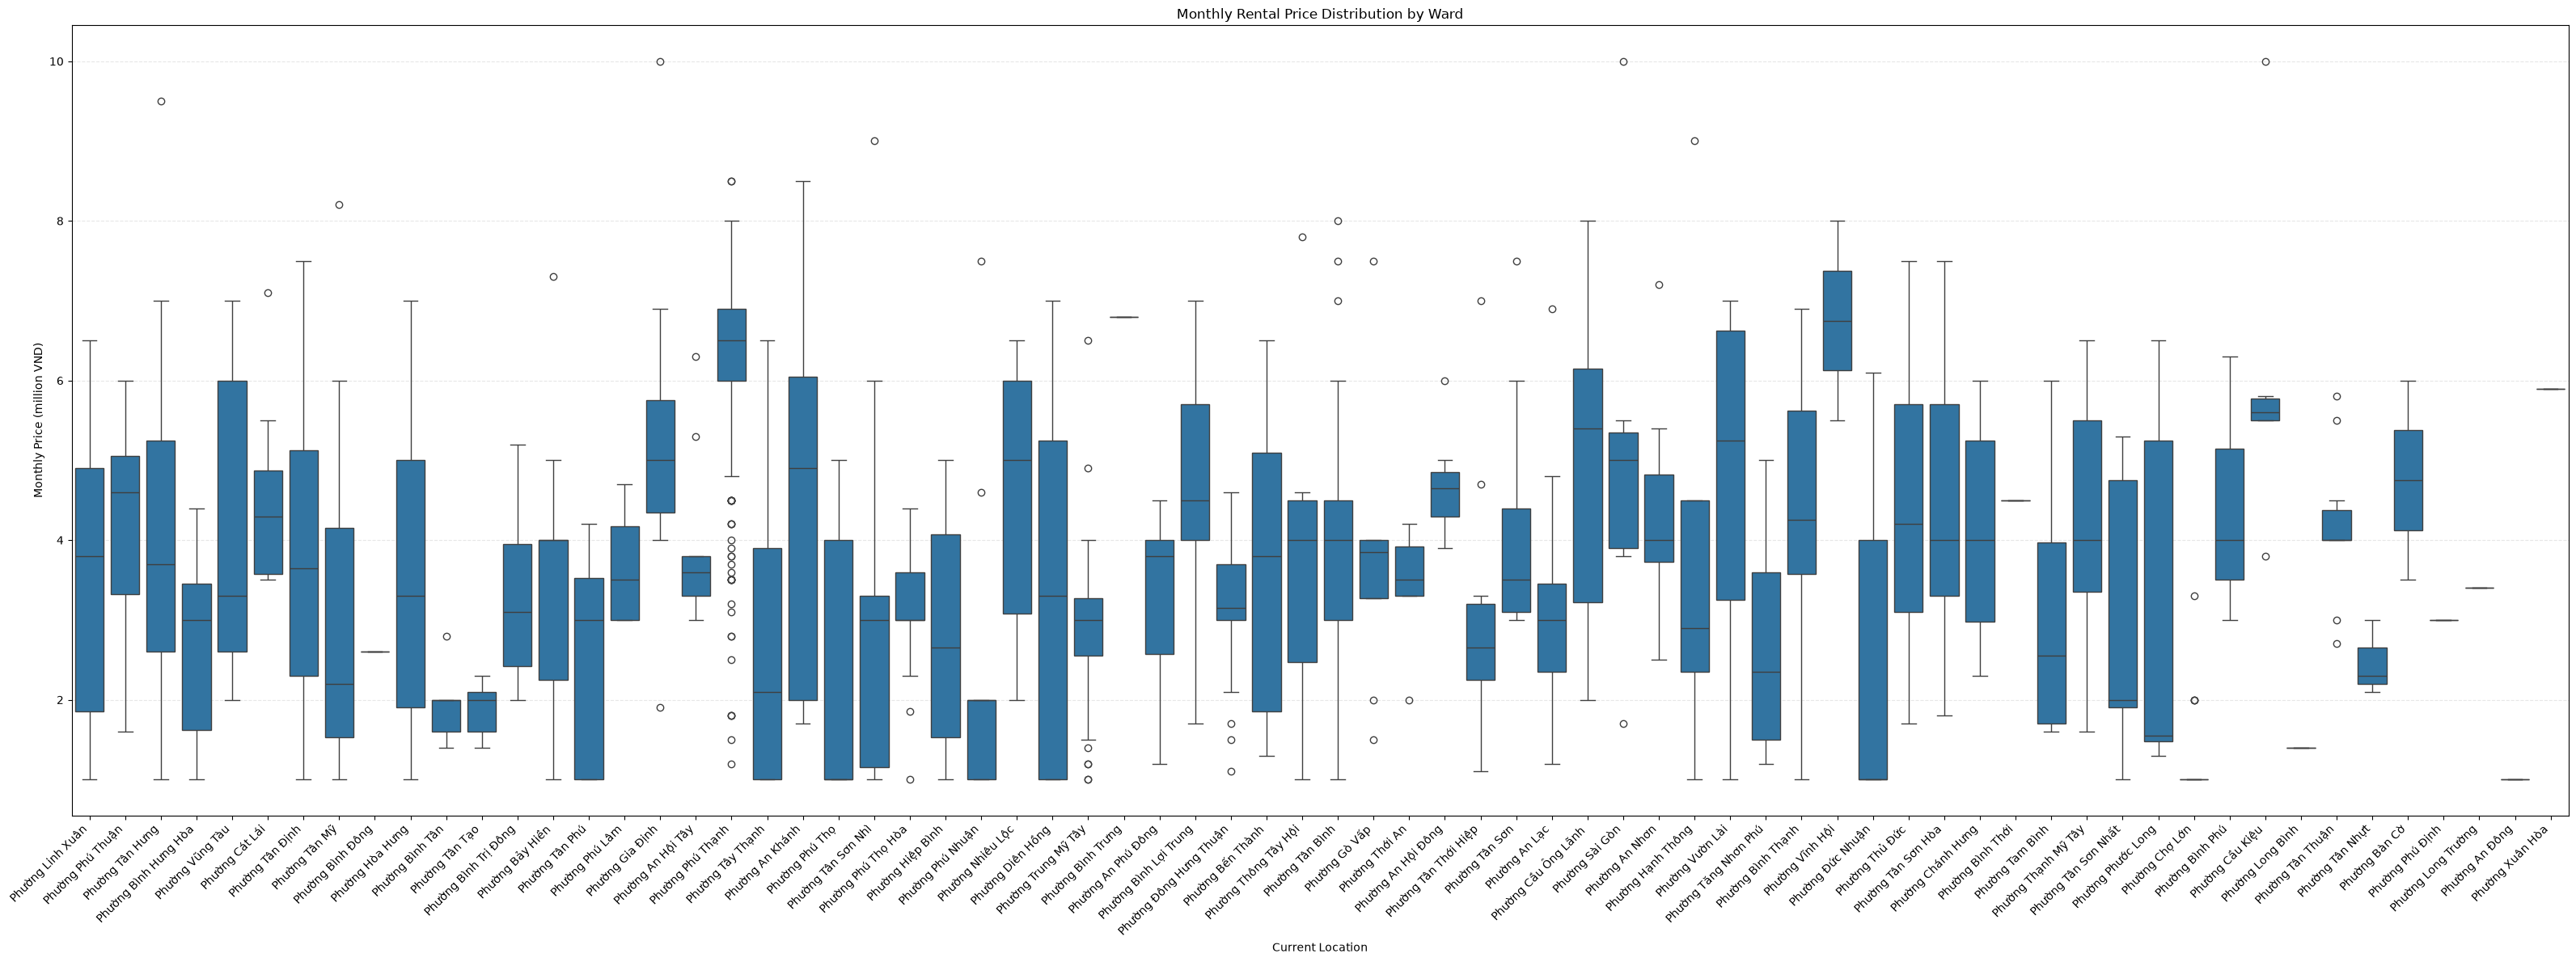

In [39]:
plt.figure(figsize=(32, 12))

sns.boxplot(
    data=plot_df_price,
    x="current_location",
    y="price_million",
)


plt.xticks(

    rotation=45,

    ha="right"

)


plt.xlabel("Current Location")

plt.ylabel(

    "Monthly Price (million VND)"

)


plt.title(

    "Monthly Rental Price Distribution by Ward"

)


plt.grid(

    axis="y",

    linestyle="--",

    alpha=0.3

)

plt.tight_layout()
plt.show()

In [40]:
# kiểm tra giá trị NaN
df_work["monthly_price"].isna().sum()

np.int64(1792)

In [41]:
df_work[
    df_work["monthly_price"].isna()
][
    [
        "domain",
        "title",
        "post_url",
        "address"
    ]
].head(20)

,domain,title,post_url,address
66,phongtro123,PHÒNG MỚI 100% – SẴN NỘI THẤT – TRUNG TÂM Q6 –...,https://phongtro123.com/phong-moi-100-san-noi-...,NaN
68,phongtro123,"PHÒNG DUXLEP ,FULL NỘI THẤT ĐANG CÓ GIÁ CỰC ƯU...",https://phongtro123.com/phong-duxlep-full-noi-...,NaN
232,phongtro123,"Phòng trọ 14m2 đường Điện Biên Phủ, Q.Bình Thạnh",https://phongtro123.com/phong-tro-14m2-duong-d...,NaN
233,phongtro123,"Phòng trọ 18m2 đường Điện Biên Phủ, Q.Bình Thạnh",https://phongtro123.com/phong-tro-18m2-duong-d...,NaN
576,phongtro123,Hẻm 1322 Nguyễn Duy Trinh Chỉ 2 Tr 5 Gần ĐH UF...,https://phongtro123.com/hem-1322-nguyen-duy-tr...,NaN
929,nhatrovn,TRỆT,https://nhatrovn.vn/cho-thue-phong-tro/ho-chi-...,"158/x/xx hoàng hoa thám, Phường 12, Quận Tân B..."
943,tromoi,Sleep Box Võ Liêm Sơn Q8 Trọn Gói Chỉ Từ 1 Tri...,https://tromoi.com/ky-tuc-xa/sleep-box-vo-liem...,"Võ Liêm Sơn, Phường 4, Quận 8 💰 Giá thuê cực t..."
951,nhatrovn,202,https://nhatrovn.vn/cho-thue-phong-tro/ho-chi-...,"Mặt tiền đường 30/4, Phường Tân Thành, Quận Tâ..."
953,nhatrovn,201,https://nhatrovn.vn/cho-thue-phong-tro/ho-chi-...,"417/xx/x Quang Trung, Phường 10, Quận Gò Vấp, ..."
966,nhatrovn,301,https://nhatrovn.vn/cho-thue-phong-tro/ho-chi-...,"26/xx Trần Quý Cáp, Phường 11, Quận Bình Thạnh..."


In [42]:
df_work.columns


Index(['domain', 'roombeacon_id', 'website_id', 'title', 'post_url',
       'monthly_price', 'area_m2', 'address', 'location', 'address_inherited',
       'latest_seen_at', 'first_seen_at', 'last_seen_at', 'active_days',
       'address_clean', 'current_location', 'price_million'],
      dtype='str')

#### Kiểm tra điểm bất thường (outlier)
- Tính IQR
=> Giá trị nào quá xa so với phần lớn dữ liệu của chính nhóm đó?

In [43]:
def get_outliers(df, group_col, value_col):
    """
    Lấy outlier theo từng nhóm (phường) dựa trên IQR
    """
    def iqr_outliers(group):
        q1 = group[value_col].quantile(0.25)
        q3 = group[value_col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return group[(group[value_col] < lower) | (group[value_col] > upper)]
    
    return df.groupby(group_col, group_keys=False).apply(iqr_outliers)

In [44]:
outliers = get_outliers(
    plot_df_price,
    group_col="current_location",
    value_col="price_million"
)

In [45]:
outliers.columns

Index(['domain', 'roombeacon_id', 'website_id', 'title', 'post_url',
       'monthly_price', 'area_m2', 'address', 'location', 'address_inherited',
       'latest_seen_at', 'first_seen_at', 'last_seen_at', 'active_days',
       'address_clean', 'price_million'],
      dtype='str')

In [46]:
from IPython.display import display

display(
    outliers[
        [
            "domain",
            "title",
            "price_million",
            "area_m2",
            "address",
            "location"
        ]
    ]
    .sort_values(
        "price_million",
        ascending=False
    )
    .head(20)
)

,domain,title,price_million,area_m2,address,location
1897,nhatot,Mô tả chi tiết,10.0,25.0,"Đường Nguyễn Cửu Vân, Phường 17, Quận Bình Thạ...","Đường Nguyễn Cửu Vân, Phường 17, Quận Bình Thạ..."
9164,mogi,1PN ban công Ngã tư Phú Nhuận/ Phan xích Long/...,10.0,30.0,"Phan Đăng Lưu, Phường 7, Quận Phú Nhuận, TPHCM","Phan Đăng Lưu, Phường 7, Quận Phú Nhuận, TPHCM"
11439,chothuenha,CHO THUÊ CĂN HỘ DỊCH VỤ VỊ TRÍ ĐẮC ĐỊA – NGAY ...,10.0,NaN,"40E Đường Nguyễn Văn Trỗi, Phường Bến Nghé, Qu...","40E Đường Nguyễn Văn Trỗi, Phường Bến Nghé, Qu..."
11441,chothuenha,"Cho thuê nhà trọ 65m2, tầng 2, khu vực trung t...",9.5,NaN,"B39, khu dân cứ kim sơn Đường 2, Phường Tân Ph...","B39, khu dân cứ kim sơn Đường 2, Phường Tân Ph..."
11341,chothuenha,CHO THUÊ TẦNG TRỆT (4x20m) - HẺM 891//Nguyê...,9.0,NaN,"891 // Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấ...","891 // Đường Nguyễn Kiệm, Phường 3, Quận Gò Vấ..."
10612,tromoi,"Mặt bằng tại 84/55 Tân Sơn Nhì, phường Tân Sơn...",9.0,NaN,"84/55 Tân Sơn Nhì, phường Tân Sơn Nhì, quận Tâ...","84/55 Tân Sơn Nhì, phường Tân Sơn Nhì, quận Tâ..."
11513,chothuephongtro,Cho thuê căn hộ full nội thất - ban công - gần...,8.5,35.0,"Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2...","Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2..."
11459,chothuephongtro,CHUNG CƯ MINI NGAY TRUNG TÂM ĐƯỜNG LÊ VĂN SỸ,8.5,35.0,"Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2...","Căn 02.34, Lầu 2, Tháp 3, The Sun Avenue, Số 2..."
10959,tromoi,"PHÒNG NGỦ TÁCH BẾP, BAN CÔNG LỚN GẦN PHÚ MỸ HƯNG",8.2,NaN,"Đường số 6, Tân Phú, Quận 7 ✨Thông tin căn hộ:...","Đường số 6, Tân Phú, Quận 7 ✨Thông tin căn hộ:..."
10918,nhatrovn,646A CỘNG HOÀ,8.0,NaN,"Mặt tiền Cộng Hoà, Phường 13, Quận Tân Bình, T...","Mặt tiền Cộng Hoà, Phường 13, Quận Tân Bình, T..."


In [47]:
outliers["price_million"].isna().sum()

np.int64(0)

#### Xóa các giá trị NaN

In [48]:
missing_price_df = df_work[
    df_work["monthly_price"].isna()
]

len(missing_price_df)

1792

In [49]:
missing_price_df[
    [
        "domain",
        "title",
        "area_m2",
        "address",
        "post_url"
    ]
].head(20)

,domain,title,area_m2,address,post_url
66,phongtro123,PHÒNG MỚI 100% – SẴN NỘI THẤT – TRUNG TÂM Q6 –...,43.0,NaN,https://phongtro123.com/phong-moi-100-san-noi-...
68,phongtro123,"PHÒNG DUXLEP ,FULL NỘI THẤT ĐANG CÓ GIÁ CỰC ƯU...",20.0,NaN,https://phongtro123.com/phong-duxlep-full-noi-...
232,phongtro123,"Phòng trọ 14m2 đường Điện Biên Phủ, Q.Bình Thạnh",14.0,NaN,https://phongtro123.com/phong-tro-14m2-duong-d...
233,phongtro123,"Phòng trọ 18m2 đường Điện Biên Phủ, Q.Bình Thạnh",18.0,NaN,https://phongtro123.com/phong-tro-18m2-duong-d...
576,phongtro123,Hẻm 1322 Nguyễn Duy Trinh Chỉ 2 Tr 5 Gần ĐH UF...,26.0,NaN,https://phongtro123.com/hem-1322-nguyen-duy-tr...
929,nhatrovn,TRỆT,20.0,"158/x/xx hoàng hoa thám, Phường 12, Quận Tân B...",https://nhatrovn.vn/cho-thue-phong-tro/ho-chi-...
943,tromoi,Sleep Box Võ Liêm Sơn Q8 Trọn Gói Chỉ Từ 1 Tri...,NaN,"Võ Liêm Sơn, Phường 4, Quận 8 💰 Giá thuê cực t...",https://tromoi.com/ky-tuc-xa/sleep-box-vo-liem...
951,nhatrovn,202,25.0,"Mặt tiền đường 30/4, Phường Tân Thành, Quận Tâ...",https://nhatrovn.vn/cho-thue-phong-tro/ho-chi-...
953,nhatrovn,201,20.0,"417/xx/x Quang Trung, Phường 10, Quận Gò Vấp, ...",https://nhatrovn.vn/cho-thue-phong-tro/ho-chi-...
966,nhatrovn,301,50.0,"26/xx Trần Quý Cáp, Phường 11, Quận Bình Thạnh...",https://nhatrovn.vn/cho-thue-phong-tro/ho-chi-...


In [50]:
missing_price_count = (
    df_work["monthly_price"]
    .isna()
    .sum()
)

missing_rate = (
    df_work["monthly_price"]
    .isna()
    .mean()
)

In [51]:
df_work = df_work.dropna(
    subset=["monthly_price"]
).copy()

In [52]:
print("Before:", len(df_work))


Before: 9842


In [53]:
df_work.head(20)

,domain,roombeacon_id,website_id,title,post_url,monthly_price,area_m2,address,location,address_inherited,latest_seen_at,first_seen_at,last_seen_at,active_days,address_clean,current_location,price_million
0,phongtro123,1774,712093,NHỮNG SLOT CUỐI CÙNG tại Trung Tâm PHÚ NHUẬN G...,https://phongtro123.com/nhung-slot-cuoi-cung-t...,1600000.0,120.0,"17/1A Đường Hồ Văn Huê, Phường Đức Nhuận, Hồ C...","17/1A Đường Hồ Văn Huê, Phường Đức Nhuận, Hồ C...",False,2026-09-14 07:29:27,2026-09-14 05:14:07,2026-09-14 07:29:27,0,"17, 1A Đường Hồ Văn Huê, Phường Đức Nhuận, Hồ ...",[],1.6
1,phongtro123,1772,712501,Cho Thuê Phòng Trọ Đường Số 9 Linh Tây,https://phongtro123.com/cho-thue-phong-tro-duo...,2500000.0,25.0,"79 Đường số 9, Phường Linh Xuân, Hồ Chí Minh","79 Đường số 9, Phường Linh Xuân, Hồ Chí Minh",False,2026-09-14 07:29:24,2026-09-14 05:14:07,2026-09-14 07:29:24,0,"79 Đường số 9, Phường Linh Xuân, Hồ Chí Minh",[Phường Linh Xuân],2.5
2,phongtro123,1770,695116,PHÒNG TRỌ 20m2 ĐƯỜNG 59 GÒ VẤP CÓ MÁY LẠNH CỬA...,https://phongtro123.com/phong-tro-20m2-duong-5...,3200000.0,20.0,"Phố số 59, Phường An Hội Tây, Hồ Chí Minh","Phố số 59, Phường An Hội Tây, Hồ Chí Minh",False,2026-09-14 07:29:21,2026-09-14 05:14:07,2026-09-14 07:29:21,0,"Phố số 59, Phường An Hội Tây, Hồ Chí Minh",[],3.2
3,phongtro123,1767,712509,CHO THUÊ 1 PHÒNG STANDAR SIÊU THOÁNG TRONG CĂN...,https://phongtro123.com/cho-thue-1-phong-stand...,7500000.0,45.0,"220 chung cư Mỹ Đức Đường Xô Viết Nghệ Tĩnh, P...","220 chung cư Mỹ Đức Đường Xô Viết Nghệ Tĩnh, P...",False,2026-09-14 07:29:18,2026-09-14 05:14:07,2026-09-14 07:29:18,0,"220 chung cư Mỹ Đức Đường Xô Viết Nghệ Tĩnh, P...",[],7.5
4,phongtro123,1766,712514,PHÒNG GÁC CÓ CỬA SỔ TRỜI THOÁNG - NGAY DƯƠNG Q...,https://phongtro123.com/phong-gac-co-cua-so-tr...,2700000.0,15.0,"496 Đường Quảng Hàm, Phường An Nhơn, Hồ Chí Minh","496 Đường Quảng Hàm, Phường An Nhơn, Hồ Chí Minh",False,2026-09-14 07:29:15,2026-09-14 05:14:07,2026-09-14 07:29:15,0,"496 Đường Quảng Hàm, Phường An Nhơn, Hồ Chí Minh",[],2.7
5,phongtro123,1763,712515,"STUDIO MỚI XÂY NGAY ĐH GTVT, NGÃ 4 HÀNG XANH C...",https://phongtro123.com/studio-moi-xay-ngay-dh...,4200000.0,20.0,"Đường Bùi Đình Túy, Phường Bình Thạnh, Hồ Chí ...","Đường Bùi Đình Túy, Phường Bình Thạnh, Hồ Chí ...",False,2026-09-14 07:29:12,2026-09-14 05:14:07,2026-09-14 07:29:12,0,"Đường Bùi Đình Túy, Phường Bình Thạnh, Hồ Chí ...",[],4.2
6,phongtro123,1760,712518,"Phòng trọ giá rẻ khu VIP Phan Xích Long, Phú N...",https://phongtro123.com/phong-tro-gia-re-khu-v...,3500000.0,20.0,"62K Đường Nguyễn Lâm, Phường Cầu Kiệu, Hồ Chí ...","62K Đường Nguyễn Lâm, Phường Cầu Kiệu, Hồ Chí ...",False,2026-09-14 07:29:09,2026-09-14 05:14:07,2026-09-14 07:29:09,0,"62K Đường Nguyễn Lâm, Phường Cầu Kiệu, Hồ Chí ...",[],3.5
7,phongtro123,1757,595846,KTX Đại Học Công Nghiệp 4 Gò Vấp free điện nướ...,https://phongtro123.com/ktx-dai-hoc-cong-nghie...,1400000.0,30.0,"60/18A Đường Huỳnh Khương An, Phường An Nhơn, ...","60/18A Đường Huỳnh Khương An, Phường An Nhơn, ...",False,2026-09-14 07:29:06,2026-09-14 05:14:07,2026-09-14 07:29:06,0,"60, 18A Đường Huỳnh Khương An, Phường An Nhơn,...",[],1.4
8,phongtro123,1755,582881,"KTX Sinh Viên HUTECH,sinh viên Đại Học Giao Th...",https://phongtro123.com/ky-tuc-xa-bao-dien-nuo...,1900000.0,200.0,"69/38/11 Đường Nguyễn Gia Trí, Phường Thạnh Mỹ...","69/38/11 Đường Nguyễn Gia Trí, Phường Thạnh Mỹ...",False,2026-09-14 07:29:03,2026-09-14 05:14:07,2026-09-14 07:29:03,0,"69, 38, 11 Đường Nguyễn Gia Trí, Phường Thạnh ...",[],1.9
9,phongtro123,1753,595869,Ký túc xá Tân Bình bao điện nước,https://phongtro123.com/ky-tuc-xa-ngay-dai-hoc...,1800000.0,30.0,"50 Đường Phạm Cự Lượng, Phường Tân Sơn Hòa, Hồ...","50 Đường Phạm Cự Lượng, Phường Tân Sơn Hòa, Hồ...",False,2026-09-14 07:29:00,2026-09-14 05:14:07,2026-09-14 07:29:00,0,"50 Đường Phạm Cự Lượng, Phường Tân Sơn Hòa, Hồ...",[],1.8
